In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("final_district_feature_table.csv")
FEATURES = [
    # Crime
    'crime_all_rt',                          # 0
    'crime_viol_rt',                         # 1
    # Education
    'pct_prof_math',                         # 2
    'pct_prof_ela',                          # 3
    # Transport
    'mta_station_count',                     # 4
    'mta_route_count_log1p',                 # 5
    'mta_station_density_per_sq_km_log1p',   # 6
    # Parks
    'parks_total_acres_log1p',               # 7
    'parks_neighborhood_park_count',         # 8
    'parks_playground_count',                # 9
    'parks_acres_per_sq_km_log1p',           # 10
]

In [3]:
# ── Cleaning & Normalization ───────────────────────────────────────────────────
# 1. Separate identifiers from features
meta_cols = ['region_id', 'region_display', 'region_name']
df_clean  = df.copy()

#Invert Crime Rate for monotonicity of features
df_clean['crime_all_rt'] = -df_clean['crime_all_rt']
df_clean['crime_viol_rt'] = -df_clean['crime_viol_rt']


# 4. Outlier detection (|z-score| > 3)
from scipy import stats

z_scores = np.abs(stats.zscore(df_clean[FEATURES]))
print("\nOutliers detected (|z| > 3):")
for i, col in enumerate(FEATURES):
    hits = df_clean['region_name'][z_scores[:, i] > 3].tolist()
    if hits:
        vals = df_clean.loc[z_scores[:, i] > 3, col].values.round(2)
        print(f"  {col}: {hits} → {vals}")

# 5. Outlier treatment — Winsorize at 1st/99th percentile
#    Clips extreme values rather than removing neighborhoods entirely.
#    Midtown's crime_all_rt of 81.4 would otherwise dominate the crime axis.
from scipy.stats.mstats import winsorize

df_winsorized = df_clean.copy()
for col in FEATURES:
    df_winsorized[col] = winsorize(df_clean[col], limits=[0.017, 0.017])

print("\nEffect of winsorizing on outlier features:")
for col in ['crime_all_rt', 'crime_viol_rt', 'mta_station_count',
            'parks_neighborhood_park_count']:
    before = df_clean[col].max()
    after  = df_winsorized[col].max()
    if before != after:
        print(f"  {col}: {before:.2f} → {after:.2f}")

# 6. Standardize (zero mean, unit variance)
#    Must be done AFTER winsorizing so outliers don't skew the scale.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df_winsorized[FEATURES].values
X_scaled = scaler.fit_transform(X)

# Derived summary feature for display in results
df_winsorized['school_avg'] = (df_winsorized['pct_prof_math'] + df_winsorized['pct_prof_ela']) / 2


Outliers detected (|z| > 3):
  crime_all_rt: ['Midtown'] → [-81.4]
  crime_viol_rt: ['Midtown'] → [-17.1]
  mta_station_count: ['Midtown'] → [31]
  mta_station_density_per_sq_km_log1p: ['Midtown'] → [2.15]
  parks_neighborhood_park_count: ['St. George/Stapleton'] → [18.]
  parks_playground_count: ['Fordham/University Heights', 'Greenpoint/Williamsburg'] → [15. 18.]

Effect of winsorizing on outlier features:
  crime_all_rt: -4.20 → -5.40
  crime_viol_rt: -1.10 → -1.20
  mta_station_count: 31.00 → 24.00
  parks_neighborhood_park_count: 18.00 → 12.00


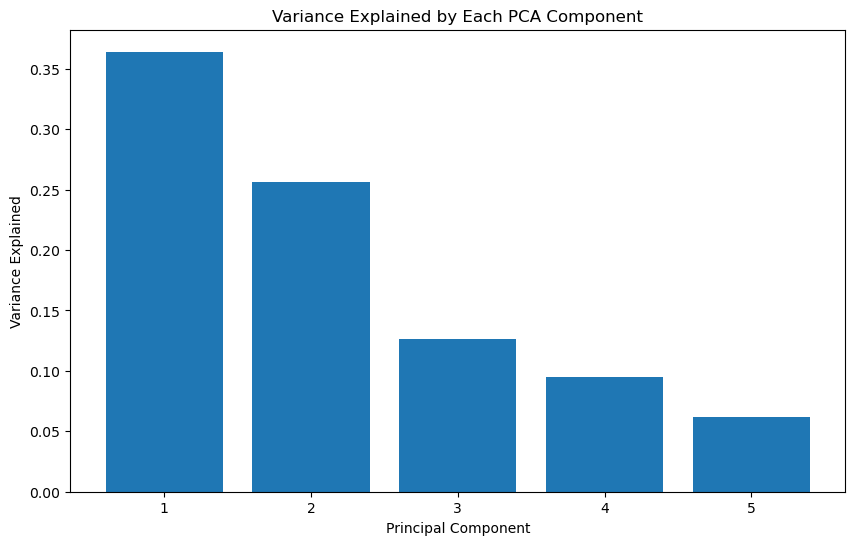

Components above 5% threshold : 5 / 5
Variance explained per component: [0.3642 0.256  0.1268 0.0951 0.0619]
Total variance retained: 90.40%
X_reduced shape: (59, 5)


In [4]:
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(10,6))

# Bar plot
plt.bar(range(1, len(explained_var) + 1), explained_var)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Variance Explained by Each PCA Component")

plt.xticks(range(1, len(explained_var) + 1))

plt.show()

# Keep only components that individually explain more than 5% of variance
threshold = 0.05
mask = pca.explained_variance_ratio_ > threshold

X_reduced = X_pca[:, mask]
var_kept = pca.explained_variance_ratio_[mask]

print(f"Components above 5% threshold : {mask.sum()} / {pca.n_components_}")
print(f"Variance explained per component: {var_kept.round(4)}")
print(f"Total variance retained: {var_kept.sum():.2%}")
print(f"X_reduced shape: {X_reduced.shape}")

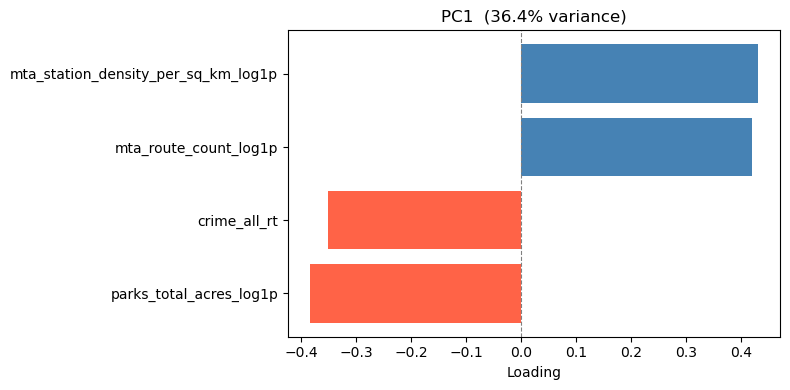

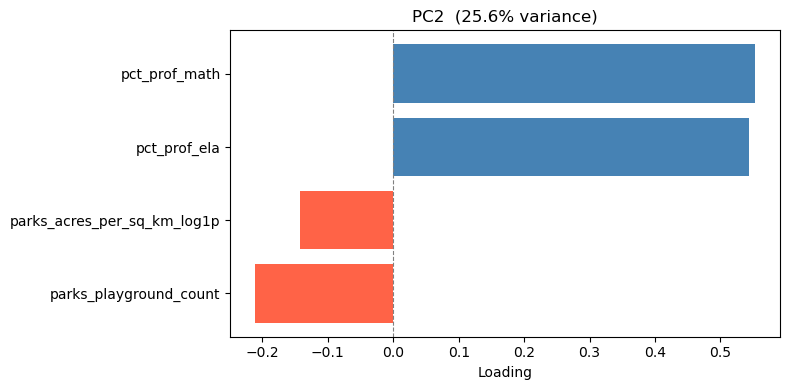

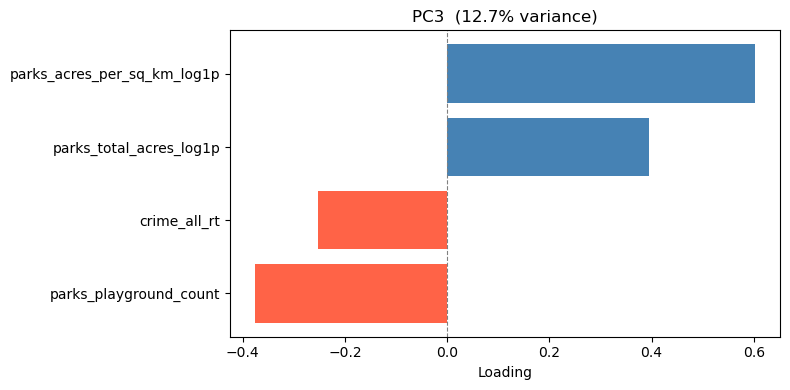

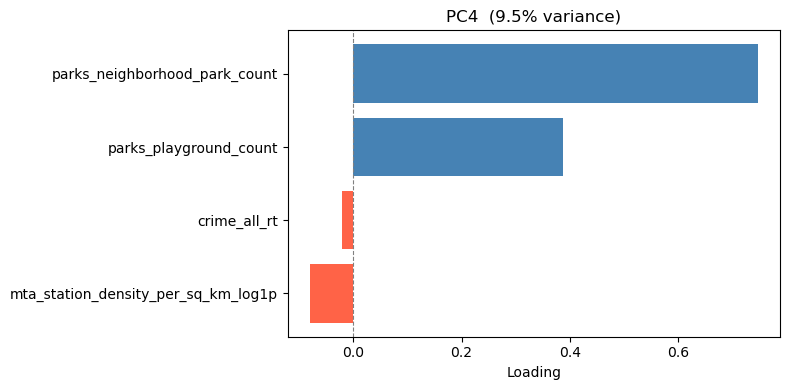

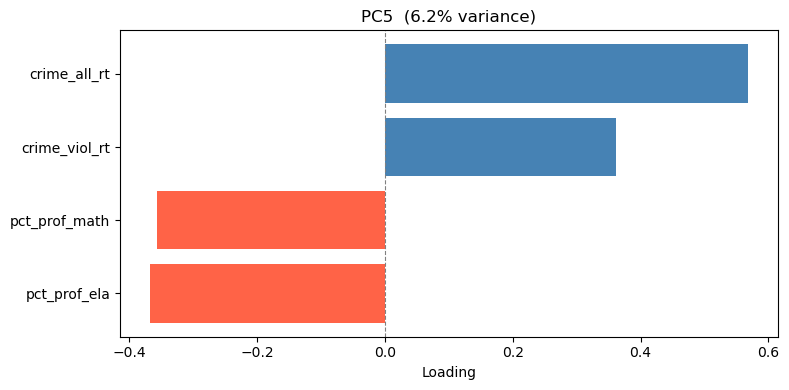

In [5]:
# PCA Component Inspection
kept_indices = np.where(mask)[0]
top_n = 5

for comp_idx in kept_indices:
    loadings = pd.Series(pca.components_[comp_idx], index=FEATURES)
    top_features = pd.concat([
        loadings.sort_values().head(top_n // 2),
        loadings.sort_values().tail(top_n // 2)
    ])

    colors = ['tomato' if v < 0 else 'steelblue' for v in top_features.values]
    variance = pca.explained_variance_ratio_[comp_idx]

    plt.figure(figsize=(8, 4))
    plt.barh(top_features.index, top_features.values, color=colors)
    plt.axvline(0, linestyle='--', color='gray', linewidth=0.8)
    plt.xlabel('Loading')
    plt.title(f'PC{comp_idx + 1}  ({variance:.1%} variance)')
    plt.tight_layout()
    plt.show()

In [6]:
# User Inputs
user_weights = {
    'Safety':  5,
    'Schools': 4,
    'Transit': 3,
    'Parks':   2,
}

PRIORITY_VECTORS = {
    'Safety':  np.array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float),
    'Schools': np.array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], dtype=float),
    'Transit': np.array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], dtype=float),
    'Parks':   np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], dtype=float),
}

for k in PRIORITY_VECTORS:
    PRIORITY_VECTORS[k] /= PRIORITY_VECTORS[k].sum()

In [7]:
# Build User Query Vector 
user_vec = np.zeros(len(FEATURES), dtype=float)
for name, pvec in PRIORITY_VECTORS.items():
    user_vec += user_weights.get(name, 0) * pvec

# Scale and project into PCA space, apply same component mask
user_scaled = scaler.transform(user_vec.reshape(1, -1))
user_pca  = pca.transform(user_scaled)
user_proj = user_pca[:, mask]

print(f"User vector (feature space): {user_vec}")
print(f"User projection (PCA space): {user_proj[0].round(4)}")

User vector (feature space): [2.5 2.5 2.  2.  1.  1.  1.  0.5 0.5 0.5 0.5]
User projection (PCA space): [ 0.0454 -1.5111 -4.5364 -5.2582  3.3394]


In [8]:
# ── Cosine Similarity ──────────────────────────────────────────────────────────
def cosine_similarity_manual(v, q):
    dot    = np.dot(v, q)
    norm_v = np.sqrt(np.dot(v, v))
    norm_q = np.sqrt(np.dot(q, q))
    if norm_v < 1e-10 or norm_q < 1e-10:
        return 0.0
    return dot / (norm_v * norm_q)

def weighted_cosine_similarity_manual(v, q, weights):
    v_w = v * weights
    q_w = q * weights
    dot    = np.dot(v_w, q_w)
    norm_v = np.sqrt(np.dot(v_w, v_w))
    norm_q = np.sqrt(np.dot(q_w, q_w))
    if norm_v < 1e-10 or norm_q < 1e-10:
        return 0.0
    return dot / (norm_v * norm_q)

def top_k_retrieval(X_reduced, user_proj, weights, k=10):
    q = user_proj[0]
    scores = np.array([
        weighted_cosine_similarity_manual(X_reduced[i], q, weights)
        for i in range(len(X_reduced))
    ])
    top_k_idx = np.argsort(scores)[::-1][:k]
    return scores, top_k_idx

In [14]:
# ── Affordability Penalty ──────────────────────────────────────────────────────
# User inputs
user_rent_budget = 1800
user_bedrooms    = 2  

BEDROOM_MAP = {
    0: ('gross_rent_0_1beds_usd', 'ah_studio_share'),
    1: ('gross_rent_0_1beds_usd', 'ah_1br_share'),
    2: ('gross_rent_2_3beds_usd', 'ah_2br_share'),
    3: ('gross_rent_2_3beds_usd', 'ah_3br_share'),
}

rent_col, share_col = BEDROOM_MAP[user_bedrooms]

# ── Layer 1: Rent Feasibility ──────────────────────────────────────────────────
# Sigmoid centered on user's budget.
# budget >> rent  →  factor near 1  (affordable)
# budget << rent  →  factor near 0  (unaffordable)

def rent_feasibility(district_rent, budget, steepness=0.003):
    if district_rent <= budget:
        return 1.0  # within budget — no penalty
    return 1 / (1 + np.exp(-steepness * (budget - district_rent)))

df_winsorized['rent_feasibility'] = df[rent_col].apply(
    lambda r: rent_feasibility(r, user_rent_budget)
)

# ── Layer 2: Unit Availability ─────────────────────────────────────────────────
# Share of affordable housing units of the user's bedroom size in the district.
# Normalized to 0–1 across all districts so it acts as a relative weight.

raw_share = df[share_col].fillna(0)
df_winsorized['unit_availability'] = raw_share / raw_share.max()

# ── Combined Affordability Factor ─────────────────────────────────────────────
# Rent feasibility is the hard constraint; availability softly modulates it.
# Adjust availability_weight to control how much unit mix matters.

availability_weight = 0.25

df_winsorized['affordability_factor'] = (
    df_winsorized['rent_feasibility'] *
    (1 - availability_weight + availability_weight * df_winsorized['unit_availability'])
)

In [15]:
# ── Retrieval ──────────────────────────────────────────────────────────────────
# Derived display feature
sim_scores, _ = top_k_retrieval(X_reduced, user_proj, var_kept, k=10)

sim_scores_clipped = np.clip(np.array(sim_scores), 0, None)
final_scores = sim_scores_clipped * df_winsorized['affordability_factor'].values

s_min, s_max = final_scores.min(), final_scores.max()

results = df_winsorized[['region_name', 'region_display']].copy()
results['similarity'] = sim_scores.round(4)
results['affordability_factor'] = df_winsorized['affordability_factor'].round(3)
results['final_score'] = final_scores.round(4)
results['crime_viol_rt'] = df_winsorized['crime_viol_rt'].round(2)
results['school_avg'] = df_winsorized['school_avg'].round(1)
results['mta_station_count'] = df_winsorized['mta_station_count']

top10 = results.sort_values('final_score', ascending=False).head(10).reset_index(drop=True)
top10.index += 1

print("Top 10 Neighborhoods\n")
print(top10[['region_name', 'similarity', 'affordability_factor',
             'final_score',
             'crime_viol_rt', 'school_avg',
             'mta_station_count']].to_string())

Top 10 Neighborhoods

                     region_name  similarity  affordability_factor  final_score  crime_viol_rt  school_avg  mta_station_count
1                  East Flatbush      0.7912                 0.851       0.6735           -6.8        50.8                  4
2             Morrisania/Crotona      0.3856                 0.885       0.3411          -13.0        38.5                  2
3     Fordham/University Heights      0.4217                 0.808       0.3409          -10.3        35.4                  7
4           Highbridge/Concourse      0.3993                 0.808       0.3226          -11.0        33.6                  7
5           Hunts Point/Longwood      0.3451                 0.873       0.3012          -13.8        35.2                  6
6           Belmont/East Tremont      0.3477                 0.852       0.2964          -13.2        32.4                  2
7   Morningside Heights/Hamilton      0.3339                 0.874       0.2918           -5.7  

In [16]:
# ── Explanation Cell ───────────────────────────────────────────────────────────
CATEGORY_FEATURES = {
    'Safety':  ['crime_all_rt', 'crime_viol_rt'],
    'Schools': ['pct_prof_math', 'pct_prof_ela'],
    'Transit': ['mta_station_count', 'mta_route_count_log1p',
                'mta_station_density_per_sq_km_log1p'],
    'Parks':   ['parks_total_acres_log1p', 'parks_neighborhood_park_count',
                'parks_playground_count', 'parks_acres_per_sq_km_log1p'],
}

n = len(df_winsorized)
cat_rank_df = pd.DataFrame(
    {cat: df_winsorized[feats].mean(axis=1).rank(ascending=False).astype(int).values
     for cat, feats in CATEGORY_FEATURES.items()},
    index=df_winsorized['region_name'].values
)

top_results = results.sort_values('final_score', ascending=False).head(10)

print(f"User: ${user_rent_budget}/mo budget · {user_bedrooms}BR\n")

for rank, (_, row) in enumerate(top_results.iterrows(), 1):
    name  = row['region_name']
    rent  = df_winsorized.loc[df_winsorized['region_name'] == name, rent_col].values[0]

    ranks = cat_rank_df.loc[name]
    if isinstance(ranks, pd.DataFrame):
        ranks = ranks.iloc[0]

    rent_note   = f"${rent:,.0f}/mo" if pd.notna(rent) else "rent unknown"
    afford_note = "within budget" if pd.notna(rent) and rent <= user_rent_budget else "over budget"

    print(f"{rank:>2}. {name}")
    print(f"    Score: {row['final_score']:.3f}  |  Similarity: {row['similarity']:.3f}  "
          f"|  Affordability: {row['affordability_factor']:.3f}  |  Rent: {rent_note} ({afford_note})")
    print(f"    " + "  |  ".join(f"{c}: #{ranks[c]} of {n}" for c in user_weights))
    print()

User: $1800/mo budget · 2BR

 1. East Flatbush
    Score: 0.673  |  Similarity: 0.791  |  Affordability: 0.851  |  Rent: $1,790/mo (within budget)
    Safety: #34 of 59  |  Schools: #37 of 59  |  Transit: #47 of 59  |  Parks: #59 of 59

 2. Morrisania/Crotona
    Score: 0.341  |  Similarity: 0.386  |  Affordability: 0.885  |  Rent: $1,340/mo (within budget)
    Safety: #54 of 59  |  Schools: #50 of 59  |  Transit: #54 of 59  |  Parks: #3 of 59

 3. Fordham/University Heights
    Score: 0.341  |  Similarity: 0.422  |  Affordability: 0.808  |  Rent: $1,720/mo (within budget)
    Safety: #51 of 59  |  Schools: #55 of 59  |  Transit: #30 of 59  |  Parks: #5 of 59

 4. Highbridge/Concourse
    Score: 0.323  |  Similarity: 0.399  |  Affordability: 0.808  |  Rent: $1,500/mo (within budget)
    Safety: #52 of 59  |  Schools: #58 of 59  |  Transit: #33 of 59  |  Parks: #19 of 59

 5. Hunts Point/Longwood
    Score: 0.301  |  Similarity: 0.345  |  Affordability: 0.873  |  Rent: $1,240/mo (within